# logic3 Results Charts

This notebook loads `logic3_results.csv` and creates three time-series charts.
`logic3` runs the CHW pumps at a constant maximum flow and instead resets the chiller leaving water temperature (CHWST) to hold the CHW return temperature (CHWRT) near a target (12 degC by default). The third chart below is specific to `logic3` and shows that reset behavior.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

CSV_PATH = Path("logic3_results.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path.cwd() / "logic3_results.csv"

results = pd.read_csv(CSV_PATH)
results["timestamp"] = pd.to_datetime(results["timestamp"])
time_hours = results["elapsed_minutes"] / 60

if "chiller_1_dT_degC" not in results.columns:
    results["chiller_1_dT_degC"] = results["chiller_1_inlet_temp_degC"] - results["chiller_1_outlet_temp_degC"]
if "chiller_2_dT_degC" not in results.columns:
    results["chiller_2_dT_degC"] = results["chiller_2_inlet_temp_degC"] - results["chiller_2_outlet_temp_degC"]

active_chiller_1 = results["chiller_1_status"].str.lower().eq("on") & results["chiller_1_mass_flow_kg_s"].gt(0.01)
active_chiller_2 = results["chiller_2_status"].str.lower().eq("on") & results["chiller_2_mass_flow_kg_s"].gt(0.01)
results["chiller_1_dT_active_degC"] = results["chiller_1_dT_degC"].where(active_chiller_1)
results["chiller_2_dT_active_degC"] = results["chiller_2_dT_degC"].where(active_chiller_2)

results.head()

,timestamp,time_s,elapsed_minutes,outdoor_temp_degC,room_internal_heat_gain_kW,room_internal_heat_gain_TR,chiller_1_status,chiller_1_inlet_temp_degC,chiller_1_outlet_temp_degC,chiller_1_dT_degC,chiller_1_mass_flow_kg_s,chiller_1_actual_cooling_kW,chiller_1_actual_cooling_TR,chiller_2_status,chiller_2_inlet_temp_degC,chiller_2_outlet_temp_degC,chiller_2_dT_degC,chiller_2_mass_flow_kg_s,chiller_2_actual_cooling_kW,chiller_2_actual_cooling_TR,actual_total_chiller_cooling_kW,actual_total_chiller_cooling_TR,cooling_tower_1_heat_extracted_kW,cooling_tower_2_heat_extracted_kW,cooling_tower_total_heat_extracted_kW,chiller_1_power_kW,chiller_2_power_kW,chiller_total_power_kW,chw_pump_1_power_kW,chw_pump_2_power_kW,cw_pump_1_power_kW,cw_pump_2_power_kW,pump_total_power_kW,cooling_tower_fan_total_power_kW,water_side_total_power_kW,chiller_performance_actual_kW_per_TR,plant_performance_actual_kW_per_TR,chiller_performance_room_gain_kW_per_TR,plant_performance_room_gain_kW_per_TR,chiller_1_chwst_setpoint_degC,chiller_2_chwst_setpoint_degC,chiller_1_request_more_chiller,chiller_2_request_more_chiller,chiller_1_dT_active_degC,chiller_2_dT_active_degC
0,2001-06-01 00:00:00,13046400,0,11.600000,200,56.869033,on,20.000000,20.000000,0.000000,4.761905,0.000000,0.000000,off,20,20,0,0,0,0,0.000000,0.000000,0.000000,0,0.000000,35.512295,0,35.512295,3.918110,0,6.995309,0,10.913419,6,52.425714,NaN,NaN,0.624458,0.921868,7.0,7,no,no,0.000000,NaN
1,2001-06-01 00:05:00,13046700,5,11.566667,200,56.869033,on,7.076038,6.998726,0.077312,4.761905,1.546234,0.439664,off,20,20,0,0,0,0,1.546234,0.439664,9.921503,0,9.921503,0.197084,0,0.197084,1.573944,0,6.995309,0,8.569252,6,14.766336,NaN,NaN,0.003466,0.259655,7.0,7,no,no,0.077312,NaN
2,2001-06-01 00:10:00,13047000,10,11.533333,200,56.869033,on,7.046026,7.000000,0.046026,3.632245,0.702147,0.199652,off,20,20,0,0,0,0,0.702147,0.199652,1.397446,0,1.397446,0.090388,0,0.090388,0.698510,0,6.995309,0,7.693819,6,13.784207,NaN,NaN,0.001589,0.242385,7.0,7,no,no,0.046026,NaN
3,2001-06-01 00:15:00,13047300,15,11.500000,200,56.869033,on,7.020184,7.000000,0.020185,2.402699,0.203689,0.057918,off,20,20,0,0,0,0,0.203689,0.057918,0.671371,0,0.671371,0.026157,0,0.026157,0.202183,0,6.995309,0,7.197492,6,13.223649,NaN,NaN,0.000460,0.232528,7.0,7,no,no,0.020185,NaN
4,2001-06-01 00:20:00,13047600,20,11.466667,200,56.869033,on,7.004746,7.000000,0.004746,1.159003,0.023102,0.006569,off,20,20,0,0,0,0,0.023102,0.006569,0.474926,0,0.474926,0.002949,0,0.002949,0.022693,0,6.995309,0,7.018002,6,13.020951,NaN,NaN,0.000052,0.228964,7.0,7,no,no,0.004746,NaN


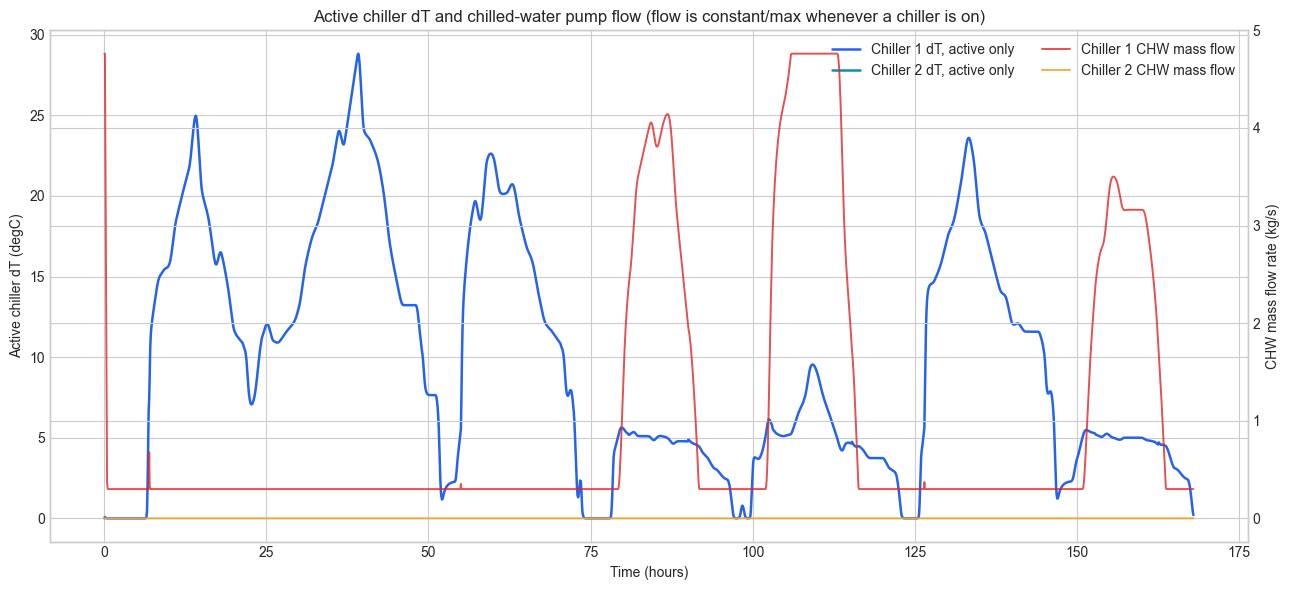

In [3]:
fig, ax_dt = plt.subplots(figsize=(13, 6))

ax_dt.plot(time_hours, results["chiller_1_dT_active_degC"], label="Chiller 1 dT, active only", color="#2563eb", linewidth=1.8)
ax_dt.plot(time_hours, results["chiller_2_dT_active_degC"], label="Chiller 2 dT, active only", color="#0891b2", linewidth=1.8)
ax_dt.set_xlabel("Time (hours)")
ax_dt.set_ylabel("Active chiller dT (degC)")

ax_flow = ax_dt.twinx()
ax_flow.plot(time_hours, results["chiller_1_mass_flow_kg_s"], label="Chiller 1 CHW mass flow", color="#dc2626", linewidth=1.4, alpha=0.8)
ax_flow.plot(time_hours, results["chiller_2_mass_flow_kg_s"], label="Chiller 2 CHW mass flow", color="#f59e0b", linewidth=1.4, alpha=0.8)
ax_flow.set_ylabel("CHW mass flow rate (kg/s)")

lines = ax_dt.get_lines() + ax_flow.get_lines()
labels = [line.get_label() for line in lines]
ax_dt.legend(lines, labels, loc="upper right", ncol=2)
ax_dt.set_title("Active chiller dT and chilled-water pump flow (flow is constant/max whenever a chiller is on)")
fig.tight_layout()
plt.show()

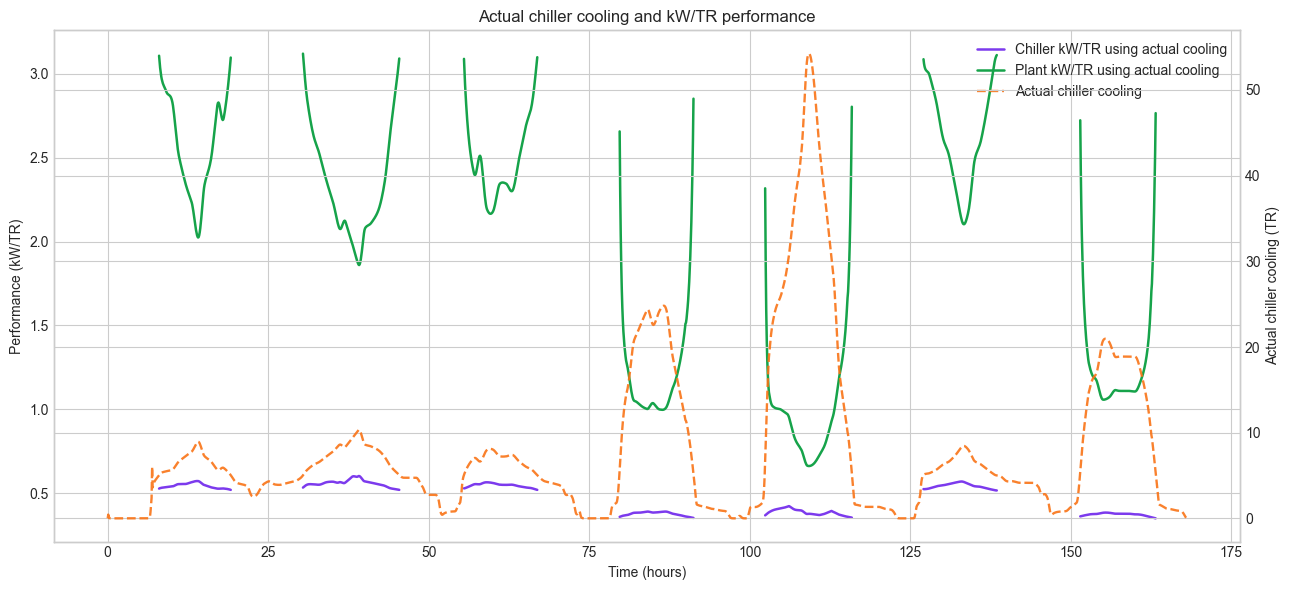

In [4]:
fig, ax_perf = plt.subplots(figsize=(13, 6))

ax_perf.plot(time_hours, results["chiller_performance_actual_kW_per_TR"], label="Chiller kW/TR using actual cooling", color="#7c3aed", linewidth=1.8)
ax_perf.plot(time_hours, results["plant_performance_actual_kW_per_TR"], label="Plant kW/TR using actual cooling", color="#16a34a", linewidth=1.8)
ax_perf.set_xlabel("Time (hours)")
ax_perf.set_ylabel("Performance (kW/TR)")

ax_load = ax_perf.twinx()
ax_load.plot(time_hours, results["actual_total_chiller_cooling_TR"], label="Actual chiller cooling", color="#f97316", linewidth=1.7, linestyle="--", alpha=0.9)
ax_load.set_ylabel("Actual chiller cooling (TR)")

lines = ax_perf.get_lines() + ax_load.get_lines()
labels = [line.get_label() for line in lines]
ax_perf.legend(lines, labels, loc="upper right")
ax_perf.set_title("Actual chiller cooling and kW/TR performance")
fig.tight_layout()
plt.show()

## CHWST reset behavior (logic2-specific)

The chart below shows the commanded chiller leaving water temperature setpoint (CHWST, solid) against the measured CHW return temperature (CHWRT, dashed), with a horizontal reference line at the 12 degC target. At high load, CHWST should sit near its floor (5 degC by default) while CHWRT tracks close to the target; at low load, CHWST should rise toward the target.

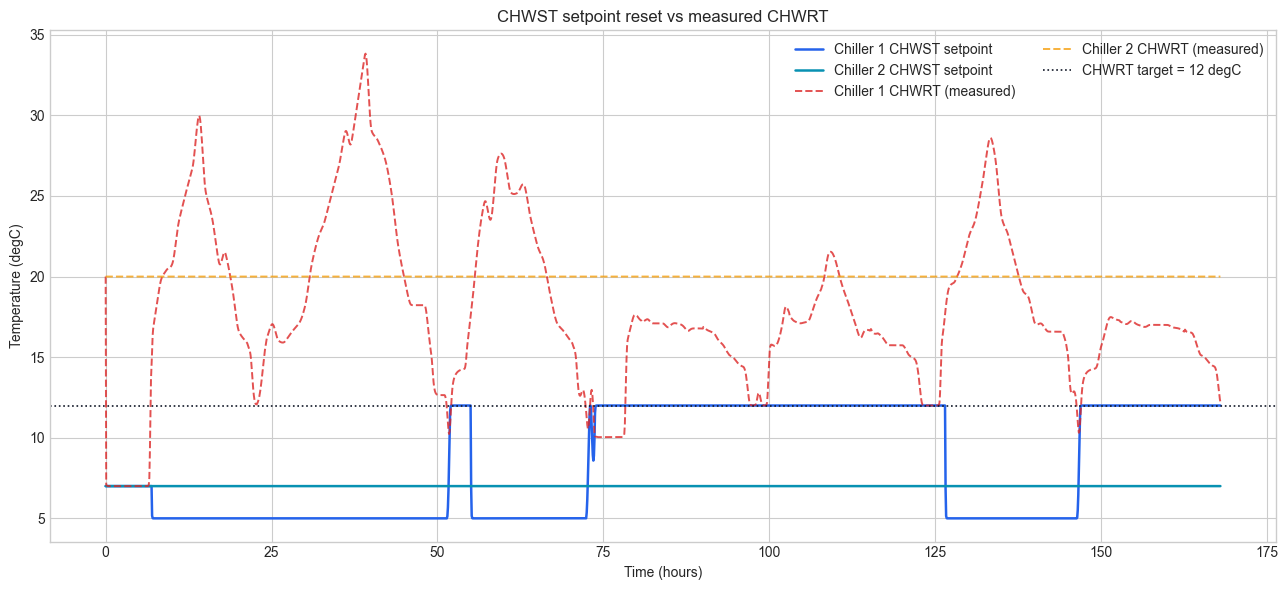

In [5]:
TCHWRTSET_DEGC = 12.0

fig, ax_temp = plt.subplots(figsize=(13, 6))

ax_temp.plot(time_hours, results["chiller_1_chwst_setpoint_degC"], label="Chiller 1 CHWST setpoint", color="#2563eb", linewidth=1.8)
ax_temp.plot(time_hours, results["chiller_2_chwst_setpoint_degC"], label="Chiller 2 CHWST setpoint", color="#0891b2", linewidth=1.8)
ax_temp.plot(time_hours, results["chiller_1_inlet_temp_degC"], label="Chiller 1 CHWRT (measured)", color="#dc2626", linewidth=1.4, linestyle="--", alpha=0.8)
ax_temp.plot(time_hours, results["chiller_2_inlet_temp_degC"], label="Chiller 2 CHWRT (measured)", color="#f59e0b", linewidth=1.4, linestyle="--", alpha=0.8)
ax_temp.axhline(TCHWRTSET_DEGC, color="#111827", linestyle=":", linewidth=1.2, label="CHWRT target = 12 degC")
ax_temp.set_xlabel("Time (hours)")
ax_temp.set_ylabel("Temperature (degC)")
ax_temp.legend(loc="upper right", ncol=2)
ax_temp.set_title("CHWST setpoint reset vs measured CHWRT")
fig.tight_layout()
plt.show()